<a href="https://colab.research.google.com/github/yunbing1999/ai-medical-robotics-exercises/blob/main/exercise_2_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI in Medical Robotics — Exercise 2.1
## Breast Cancer Wisconsin (Diagnostic) — Data Visualization

This notebook helps you explore the dataset used in **Exercise 2.1**: load the data, visualize it
in a few different ways, and then try out a simple classification rule.

You do **not** need to write new code — run each cell from top to bottom (▶ or `Shift+Enter`).
In two cells you may change a single number to try out your own rule. Use the results to answer
the two questions on the exercise sheet.

**Dataset source:** Wolberg, W., Mangasarian, O., Street, N., & Street, W. (1993). *Breast Cancer
Wisconsin (Diagnostic)* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5DW2B

## 1. Import libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

sns.set_theme(style="whitegrid")
plt.rcParams["figure.facecolor"] = "white"

# Light colour scheme used throughout this notebook
BENIGN, MALIGNANT = "#7FD4E3", "#F4A6C8"
PALETTE = {"Benign": BENIGN, "Malignant": MALIGNANT}
%matplotlib inline

## 2. Load the dataset

We use the built-in copy of this dataset from `scikit-learn` so the notebook runs anywhere without
uploading a file. It is the same data as the UCI "Breast Cancer Wisconsin (Diagnostic)" dataset used
on the exercise sheet (569 cases).

We keep the four features from the exercise sheet (`radius_mean`, `texture_mean`, `perimeter_mean`,
`area_mean`) and turn the numeric target into a readable `Diagnosis` column (`Benign` / `Malignant`).

In [ ]:
data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)

rename_map = {
    "mean radius": "radius_mean",
    "mean texture": "texture_mean",
    "mean perimeter": "perimeter_mean",
    "mean area": "area_mean",
}
df = df[list(rename_map.keys())].rename(columns=rename_map)

# data.target: 0 = malignant, 1 = benign (see data.target_names)
df["Diagnosis"] = [data.target_names[i].capitalize() for i in data.target]

FEATURES = ["radius_mean", "texture_mean", "perimeter_mean", "area_mean"]

print(f"{len(df)} cases loaded.")
df.head()

569 cases loaded.


,radius_mean,texture_mean,perimeter_mean,area_mean,Diagnosis
0,17.99,10.38,122.80,1001.0,Malignant
1,20.57,17.77,132.90,1326.0,Malignant
2,19.69,21.25,130.00,1203.0,Malignant
3,11.42,20.38,77.58,386.1,Malignant
4,20.29,14.34,135.10,1297.0,Malignant


## 3. How many Benign vs. Malignant cases are there?

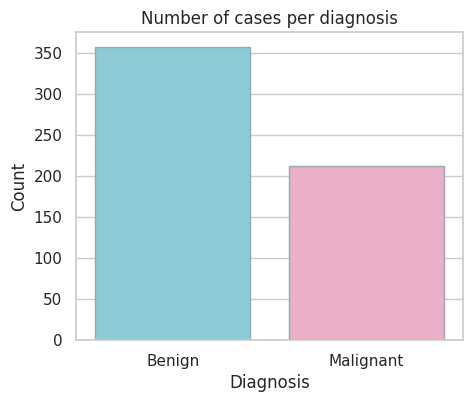

Diagnosis
Benign       357
Malignant    212


In [ ]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="Diagnosis", hue="Diagnosis", palette=PALETTE,
              order=["Benign", "Malignant"], edgecolor="#9AA5B1", legend=False)
plt.title("Number of cases per diagnosis")
plt.ylabel("Count")
plt.show()

print(df["Diagnosis"].value_counts().to_string())

## 4. Pairplot — how do the four features relate to each other?

Every feature is plotted against every other feature, coloured by diagnosis. The diagonal shows the
distribution of each single feature per class.

*Look for:* in which panels do the two colours form clearly separated groups, and in which do they
overlap? (Question 1)

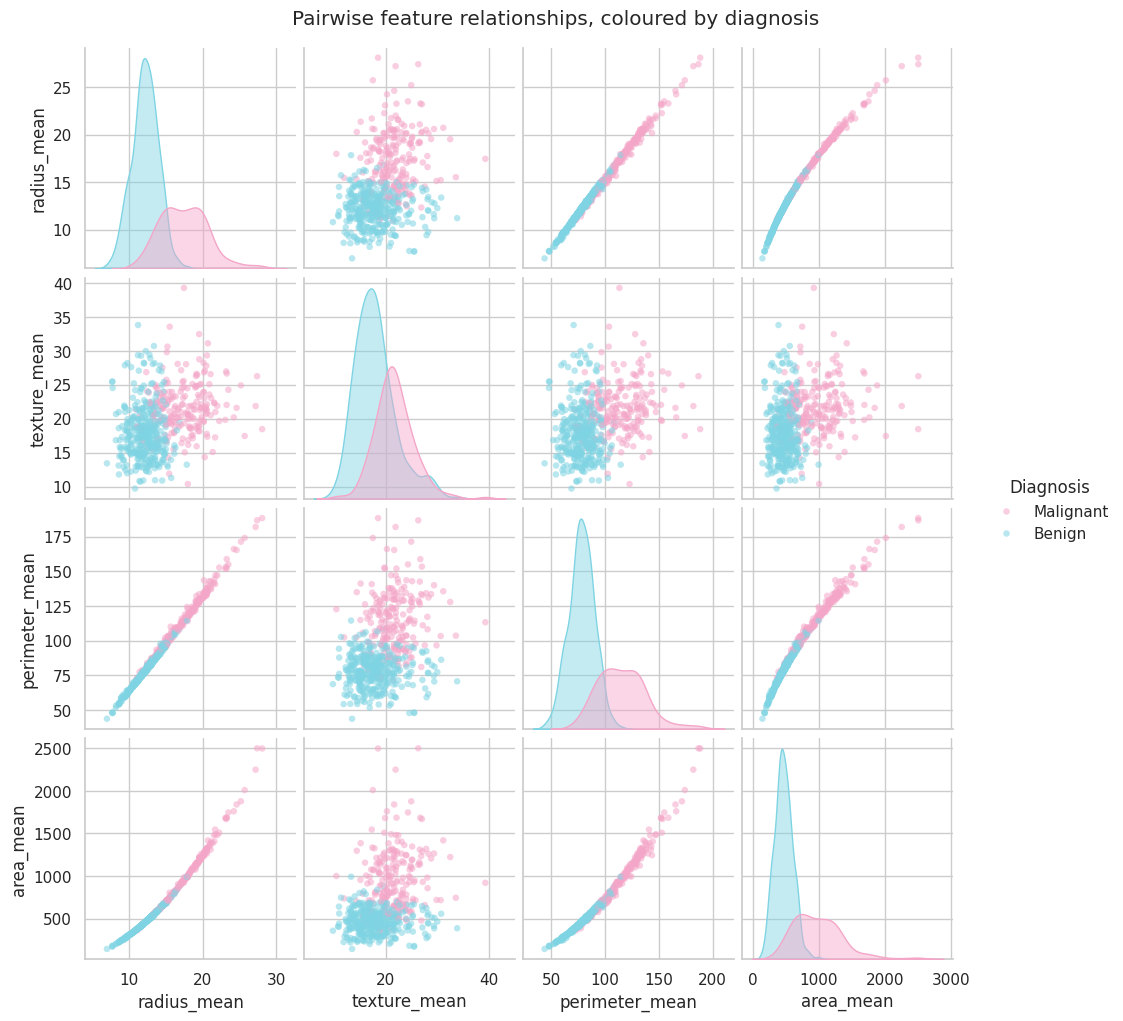

In [ ]:
sns.pairplot(
    df,
    hue="Diagnosis",
    palette=PALETTE,
    vars=FEATURES,
    diag_kind="kde",
    plot_kws=dict(alpha=0.55, s=22, edgecolor="none"),
    diag_kws=dict(fill=True, alpha=0.45, linewidth=1),
)
plt.suptitle("Pairwise feature relationships, coloured by diagnosis", y=1.02)
plt.show()

## 5. Correlation heatmap

How strongly are the four features related to each other?

*Look for:* which features carry almost the same information, and which one is different?

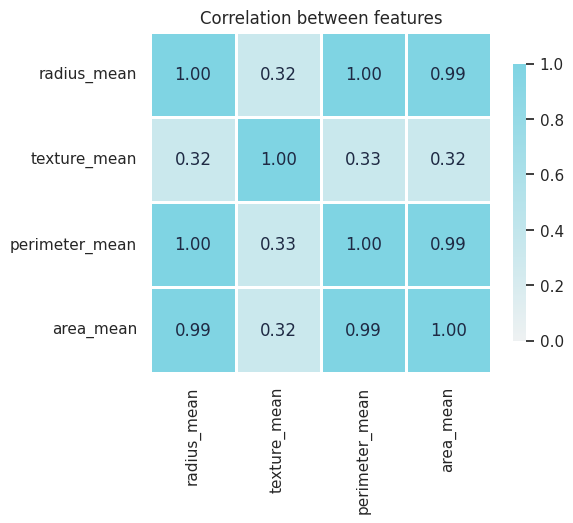

In [ ]:
corr = df[FEATURES].corr()

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap=sns.light_palette(BENIGN, as_cmap=True), vmin=0, vmax=1, square=True,
            linewidths=1, linecolor="white", cbar_kws={"shrink": 0.8},
            annot_kws={"color": "#1F2A44"})
plt.title("Correlation between features")
plt.show()

## 6. Boxplots — which single feature separates the classes best?

For each feature, this compares the distribution of Benign and Malignant cases.

*Look for:* the feature whose two boxes overlap the least is the most useful one on its own.
(Question 1)

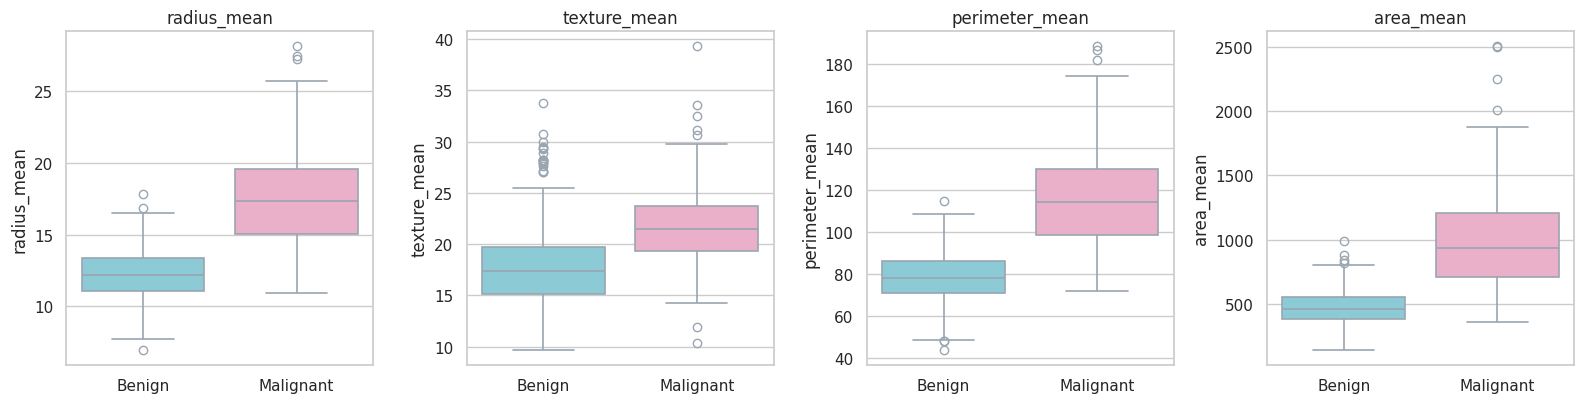

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))

for ax, feature in zip(axes, FEATURES):
    sns.boxplot(data=df, x="Diagnosis", y=feature, hue="Diagnosis", palette=PALETTE,
                order=["Benign", "Malignant"], legend=False, linecolor="#9AA5B1",
                linewidth=1.2, ax=ax)
    ax.set_title(feature)
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

## 7. Try out a threshold rule

The simplest possible strategy is a single cutoff on one feature:
`radius_mean > threshold  →  Malignant`.

Change the value of `threshold` below and re-run the cell to see how well your rule does.

Rule: radius_mean > 15.0  ->  Malignant
correct                                 : 506 of 569 (88.9%)
malignant cases missed (called Benign)  : 51
benign cases wrongly called Malignant   : 12


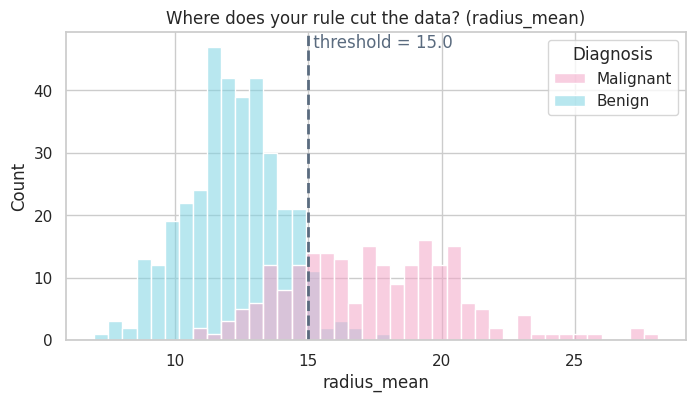

In [ ]:
threshold = 15.0        # <-- change this number and run the cell again
feature = "radius_mean"    # <-- you can also try "area_mean" or "texture_mean"

prediction = np.where(df[feature] > threshold, "Malignant", "Benign")

correct = (prediction == df["Diagnosis"]).sum()
missed_malignant = ((prediction == "Benign") & (df["Diagnosis"] == "Malignant")).sum()
false_alarm = ((prediction == "Malignant") & (df["Diagnosis"] == "Benign")).sum()

print(f"Rule: {feature} > {threshold}  ->  Malignant")
print(f"correct                                 : {correct} of {len(df)} ({correct / len(df):.1%})")
print(f"malignant cases missed (called Benign)  : {missed_malignant}")
print(f"benign cases wrongly called Malignant   : {false_alarm}")

plt.figure(figsize=(8, 4))
sns.histplot(data=df, x=feature, hue="Diagnosis", palette=PALETTE, bins=40,
             alpha=0.55, edgecolor="white")
plt.axvline(threshold, color="#5A6B7F", linestyle="--", linewidth=2)
plt.text(threshold, plt.ylim()[1] * 0.95, f" threshold = {threshold}", color="#5A6B7F")
plt.title(f"Where does your rule cut the data? ({feature})")
plt.show()

*Look for:* both kinds of mistakes. Which of the two is worse in a clinical setting? (Question 1)

## 8. One case in, one diagnosis out

A classification strategy takes the **measurements of one case as input** and returns a
**diagnosis as output**. Here your rule is applied to a single patient case.

In [ ]:
case_index = 0          # <-- try other rows, e.g. 19 or 62

case = df.iloc[case_index]

print("INPUT  (measurements of one case)")
for f in FEATURES:
    print(f"   {f:<16} = {case[f]:.2f}")

predicted = "Malignant" if case[feature] > threshold else "Benign"

print(f"\nRULE   {feature} > {threshold} ?")
print(f"OUTPUT predicted diagnosis : {predicted}")
print(f"       true diagnosis      : {case['Diagnosis']}")

INPUT  (measurements of one case)
   radius_mean      = 17.99
   texture_mean     = 10.38
   perimeter_mean   = 122.80
   area_mean        = 1001.00

RULE   radius_mean > 15.0 ?
OUTPUT predicted diagnosis : Malignant
       true diagnosis      : Malignant


## 9. Who finds the rule: you or the computer?

The rule above always has the same form — only the *number* changes. There are two ways to get
that number, and they correspond to the two approaches in **Question 2**.

(A) chosen by you       : radius_mean > 13.0   -> 78.2% correct
(B) found from the data : radius_mean > 15.03  -> 88.9% correct


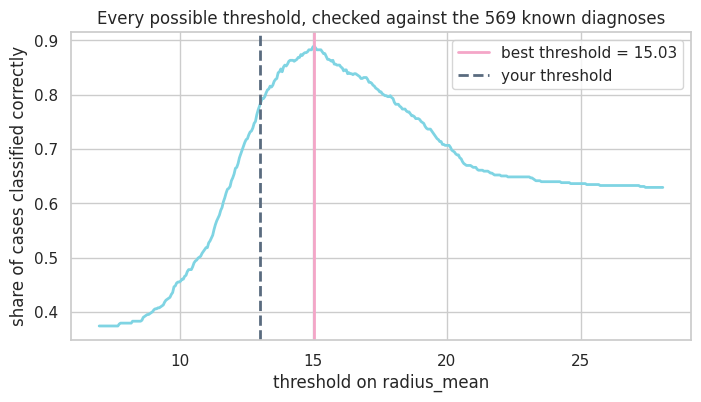

In [ ]:
def accuracy(t, feature="radius_mean"):
    return (np.where(df[feature] > t, "Malignant", "Benign") == df["Diagnosis"]).mean()

# (A) A human chooses the threshold from experience
my_threshold = 13.0     # <-- a first guess by eye; replace it with your own value from section 7
print(f"(A) chosen by you       : {feature} > {my_threshold:<6} -> {accuracy(my_threshold):.1%} correct")

# (B) The computer tries many thresholds on the 569 labelled cases and keeps the best one
candidates = np.arange(df[feature].min(), df[feature].max(), 0.05)
scores = [accuracy(t) for t in candidates]
best_t = candidates[int(np.argmax(scores))]
print(f"(B) found from the data : {feature} > {best_t:<6.2f} -> {max(scores):.1%} correct")

plt.figure(figsize=(8, 4))
plt.plot(candidates, scores, color="#7FD4E3", linewidth=2)
plt.axvline(best_t, color="#F4A6C8", linewidth=2, label=f"best threshold = {best_t:.2f}")
plt.axvline(my_threshold, color="#5A6B7F", linestyle="--", linewidth=2, label="your threshold")
plt.xlabel(f"threshold on {feature}")
plt.ylabel("share of cases classified correctly")
plt.title("Every possible threshold, checked against the 569 known diagnoses")
plt.legend()
plt.show()

*Look for:* both rules look exactly the same — the difference is only **who determined the number**,
a human from medical knowledge or a computer from labelled data. (Question 2)

---
## Back to Exercise 2.1

Use what you saw here to answer the two questions on the exercise sheet:

1. How could a new case be classified as Benign or Malignant based on these measurements? Which
   features would you use, what would the rule look like, and what are the input and the output of
   your strategy?
2. Your strategy could be created by a pathologist writing the rule down, or by a computer deriving
   it from the 569 cases with known diagnosis. Which is knowledge-based AI and which is data-driven
   AI, and what are the advantages and disadvantages of each?